Exploratory Data Analysis (EDA)

Airbnb data engineering pipeline – Amsterdam

Import Libraries

In [36]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.express as px

# Better plot appearance
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Show all columns when needed
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


Load the Cleaned Dataset

In [41]:
master = pd.read_parquet("../data/processed/master_listings.parquet")

print(master.shape)
master.head()



(10480, 120)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,property_type_normalized,host_tenure_years,price_per_bedroom,host_segment,city,_is_valid,review_count,latest_review_date,earliest_review_date,has_text_review_count,active_review_months,reviews_per_month_computed,total_days,booked_days,available_days,occupancy_rate,weekend_booked_days,weekend_total_days,weekday_booked_days,weekday_total_days,peak_month,weekend_occupancy_rate,weekday_occupancy_rate,review_frequency,estimated_annual_revenue_computed,price_tier,is_high_performer,days_since_last_review,neighbourhood_median_price,neighbourhood_mean_price,neighbourhood_min_price,neighbourhood_max_price,neighbourhood_price_std,neighbourhood_listing_count,neighbourhood_avg_rating,neighbourhood_avg_cleanliness,neighbourhood_avg_location,neighbourhood_avg_occupancy,neighbourhood_superhost_pct,neighbourhood_price_rank,price_vs_neighbourhood_median
0,27886,https://www.airbnb.com/rooms/27886,20250911031321,2025-09-11,city scrape,"Romantic, stylish B&B houseboat in canal district",Stylish and romantic houseboat on fantastic hi...,"Central, quiet, safe, clean and beautiful.",https://a0.muscache.com/pictures/02c2da9d-660e...,97647,https://www.airbnb.com/users/show/97647,Flip,2010-03-23,"Amsterdam, Netherlands","Marjan works in ""eye"" the dutch filmmuseum, an...",within an hour,100.0,97.0,True,https://a0.muscache.com/im/users/97647/profile...,https://a0.muscache.com/im/users/97647/profile...,Westelijke Eilanden,1.0,1.0,"['email', 'phone']",True,True,"Amsterdam, North Holland, Netherlands",Centrum-West,,52.38761,4.89188,Private room in houseboat,Private room,2,1.5,1.5 baths,1.0,1.0,"[""Canal view"", ""Coffee"", ""Private backyard \u2...",132.0,3,356,3.0,3.0,30.0,30.0,3.0,30.0,,True,2,5,16,17,2025-09-11,311,33,3,17,26,255,33660.0,2012-01-09,2025-09-07,4.92,4.90,4.94,4.95,4.93,4.90,4.78,0363 974D 4986 7411 88D8,False,1,0,1,0,1.87,Other,16.26,132.0,Single-listing,Amsterdam,True,311.0,2025-09-07,2012-01-09,310.0,163.93,1.8972,365,348,17,0.9534,101,104,247,261,1.0,0.9712,0.9464,1.8972,45934.81,Mid-range (€81–€150),True,293.0,245.5,315.88,58.0,10000.0,429.96,1207,4.803,4.760,4.931,0.6762,31.3,2,-46.23
1,28871,https://www.airbnb.com/rooms/28871,20250911031321,2025-09-11,city scrape,Comfortable double room,Basic bedroom in the center of Amsterdam.,"Flower market , Leidseplein , Rembrantsplein",https://a0.muscache.com/pictures/160889/362340...,124245,https://www.airbnb.com/users/show/124245,Edwin,2010-05-13,"Amsterdam, Netherlands",Hi,within an hour,100.0,99.0,True,https://a0.muscache.com/im/pictures/user/9986b...,https://a0.muscache.com/im/pictures/user/9986b...,Amst

In [42]:
REPORT_DIR = Path('../reports')
REPORT_DIR.mkdir(exist_ok=True)

In [3]:
master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10480 entries, 0 to 10479
Columns: 120 entries, id to price_vs_neighbourhood_median
dtypes: Int64(1), bool(3), category(2), datetime64[ns](7), float64(48), int64(28), object(31)
memory usage: 9.3+ MB


In [11]:
missing = (
    master.isna()
      .sum()
      .sort_values(ascending=False)
)

missing.head(30)

price_per_bedroom                    4782
price                                4606
estimated_revenue_l365d              4606
price_tier                           4606
estimated_annual_revenue_computed    4606
price_vs_neighbourhood_median        4606
host_response_rate                   3797
host_acceptance_rate                 2430
review_scores_cleanliness            1098
last_review                          1097
first_review                         1097
latest_review_date                   1097
review_scores_checkin                1097
review_count                         1097
review_scores_value                  1097
review_scores_location               1097
review_scores_communication          1097
review_scores_accuracy               1097
review_scores_rating                 1097
has_text_review_count                1097
review_frequency                     1097
days_since_last_review               1097
reviews_per_month_computed           1097
active_review_months              

In [14]:
master.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,10480.0,NaN,NaN,NaN,592546397015783936.0,27886.0,26293728.25,689347426246034560.0,1119610195817792000.0,1506287353709120512.0,562067488034233600.0
listing_url,10480,10480,https://www.airbnb.com/rooms/1506287353709120640,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scrape_id,10480.0,NaN,NaN,NaN,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,0.0
last_scraped,10480,NaN,NaN,NaN,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,NaN
source,10480,2,city scrape,5932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
neighbourhood_avg_location,10480.0,NaN,NaN,NaN,4.816578,4.469,4.751,4.844,4.885,4.931,0.0919
neighbourhood_avg_occupancy,10480.0,NaN,NaN,NaN,0.742327,0.6352,0.7165,0.758,0.7801,0.8168,0.052576
neighbourhood_superhost_pct,10480.0,NaN,NaN,NaN,17.771927,6.7,13.4,15.6,19.7,31.3,6.373817
neighbourhood_price_rank,10480.0,<NA>,<NA>,<NA>,6.253435,1.0,3.0,5.0,10.0,22.0,4.962007


In [12]:
missing = pd.DataFrame({
    "Missing Count": master.isnull().sum(),
    "Missing %": (master.isnull().mean() * 100).round(2)
})

missing = (
    missing[missing["Missing Count"] > 0]
    .sort_values("Missing %", ascending=False)
)

missing

,Missing Count,Missing %
price_per_bedroom,4782,45.63
price_vs_neighbourhood_median,4606,43.95
estimated_annual_revenue_computed,4606,43.95
estimated_revenue_l365d,4606,43.95
price_tier,4606,43.95
price,4606,43.95
host_response_rate,3797,36.23
host_acceptance_rate,2430,23.19
review_scores_cleanliness,1098,10.48
reviews_per_month_computed,1097,10.47


In [15]:
master.describe().T

,count,mean,min,25%,50%,75%,max,std
id,10480.0,592546397015783936.0,27886.0,26293728.25,689347426246034560.0,1119610195817792000.0,1506287353709120512.0,562067488034233600.0
scrape_id,10480.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,20250911031321.0,0.0
last_scraped,10480,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,2025-09-11 00:00:00,NaN
host_id,10480.0,134501911.112691,1662.0,12777805.25,45478429.5,187719627.75,717346955.0,180435871.998197
host_since,10477,2016-07-31 06:28:24.991887360,2008-08-11 00:00:00,2014-03-08 00:00:00,2015-10-09 00:00:00,2018-05-06 00:00:00,2025-09-05 00:00:00,NaN
...,...,...,...,...,...,...,...,...
neighbourhood_avg_location,10480.0,4.816578,4.469,4.751,4.844,4.885,4.931,0.0919
neighbourhood_avg_occupancy,10480.0,0.742327,0.6352,0.7165,0.758,0.7801,0.8168,0.052576
neighbourhood_superhost_pct,10480.0,17.771927,6.7,13.4,15.6,19.7,31.3,6.373817
neighbourhood_price_rank,10480.0,6.253435,1.0,3.0,5.0,10.0,22.0,4.962007


In [16]:
numeric_cols = [

    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "availability_365",
    "occupancy_rate",
    "estimated_annual_revenue_computed",
    "host_tenure_years"

]

In [17]:
summary = master[numeric_cols].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
price,5874.0,336.785155,1985.661882,35.00,161.000,222.0000,314.000,80018.00
accommodates,10480.0,2.920515,1.276192,1.00,2.000,2.0000,4.000,16.00
bedrooms,10174.0,1.554158,0.886438,0.00,1.000,1.0000,2.000,17.00
beds,10480.0,1.666794,1.273035,0.00,1.000,1.0000,2.000,33.00
number_of_reviews,10480.0,47.813359,131.507440,0.00,3.000,10.0000,30.000,5097.00
reviews_per_month,10480.0,0.894132,2.203412,0.00,0.140,0.3500,0.780,99.42
review_scores_rating,9383.0,4.844096,0.257871,1.00,4.790,4.9200,5.000,5.00
availability_365,10480.0,93.999809,122.276158,0.00,0.000,20.0000,173.000,365.00
occupancy_rate,10480.0,0.742322,0.334997,0.00,0.526,0.9452,1.000,1.00
estimated_annual_revenue_computed,5874.0,61454.412986,404169.390761,0.00,19761.250,44703.7400,72747.745,22164865.97


In [20]:
summary["missing_%"] = (
    master[numeric_cols]
      .isna()
      .mean()*100
).round(2)

summary

,count,mean,std,min,25%,50%,75%,max,median,missing_%
price,5874.0,336.785155,1985.661882,35.00,161.000,222.0000,314.000,80018.00,222.0000,43.95
accommodates,10480.0,2.920515,1.276192,1.00,2.000,2.0000,4.000,16.00,2.0000,0.00
bedrooms,10174.0,1.554158,0.886438,0.00,1.000,1.0000,2.000,17.00,1.0000,2.92
beds,10480.0,1.666794,1.273035,0.00,1.000,1.0000,2.000,33.00,1.0000,0.00
number_of_reviews,10480.0,47.813359,131.507440,0.00,3.000,10.0000,30.000,5097.00,10.0000,0.00
reviews_per_month,10480.0,0.894132,2.203412,0.00,0.140,0.3500,0.780,99.42,0.3500,0.00
review_scores_rating,9383.0,4.844096,0.257871,1.00,4.790,4.9200,5.000,5.00,4.9200,10.47
availability_365,10480.0,93.999809,122.276158,0.00,0.000,20.0000,173.000,365.00,20.0000,0.00
occupancy_rate,10480.0,0.742322,0.334997,0.00,0.526,0.9452,1.000,1.00,0.9452,0.00
estimated_annual_revenue_computed,5874.0,61454.412986,404169.390761,0.00,19761.250,44703.7400,72747.745,22164865.97,44703.7400,43.95


In [21]:
summary.to_csv(
    "../Reports/summary_statistics.csv"
)

In [46]:
valid = master[master["price"].notna()].copy()
print(valid.shape)

print(f'Total listings       : {len(master):,}')
print(f'Valid price listings : {len(valid):,}')
print(f'Price range          : {valid["price"].min():.0f} – {valid["price"].max():,.0f}')
print(f'Median price         : {valid["price"].median():.0f}')
print(f'Mean price           : {valid["price"].mean():.0f}  (note: mean > median due to luxury outliers)')

(5874, 120)
Total listings       : 10,480
Valid price listings : 5,874
Price range          : 35 – 80,018
Median price         : 222
Mean price           : 337  (note: mean > median due to luxury outliers)


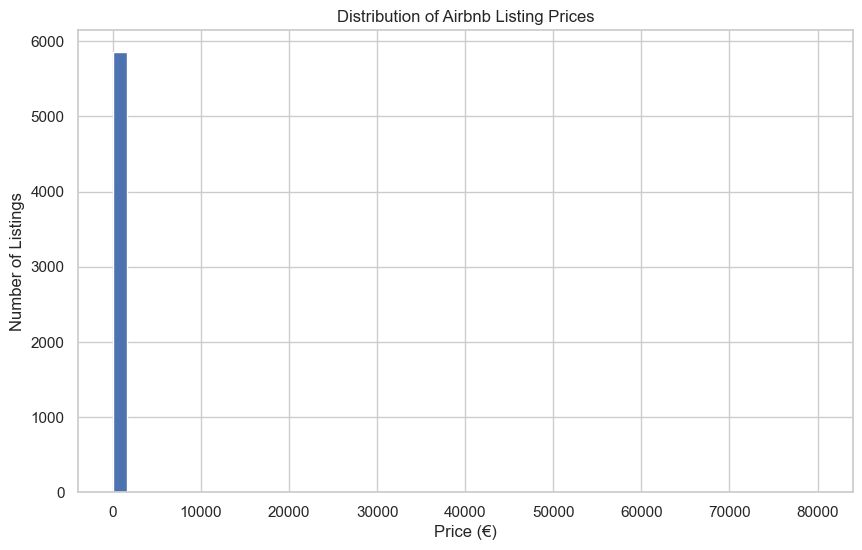

In [31]:
plt.figure(figsize=(10,6))

plt.hist(
    valid["price"],
    bins=50
)

plt.xlabel("Price (€)")
plt.ylabel("Number of Listings")
plt.title("Distribution of Airbnb Listing Prices")

plt.show()

In [33]:
valid["room_type"].value_counts()

room_type
Entire home/apt    4532
Private room       1274
Hotel room           38
Shared room          30
Name: count, dtype: int64

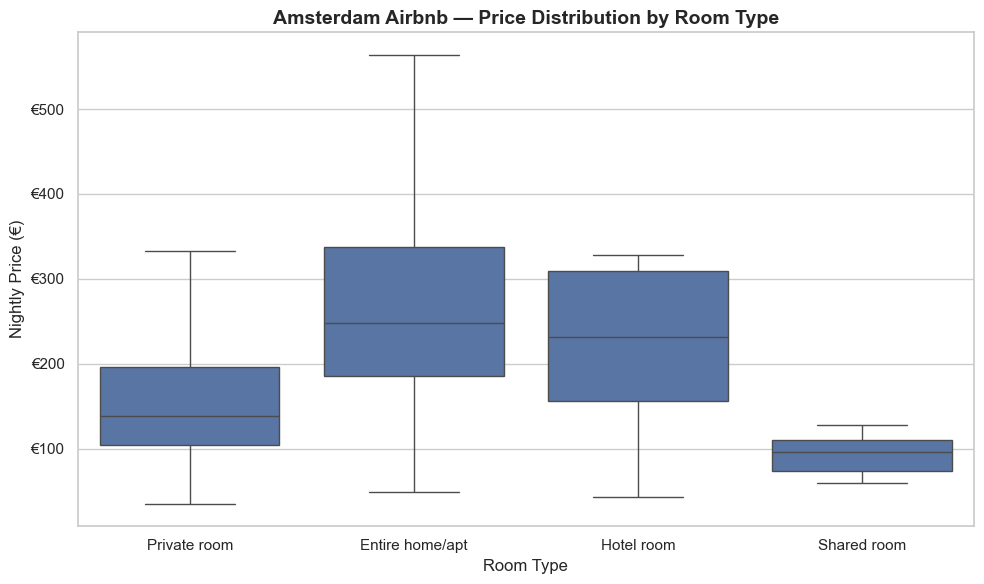


📋 Business Interpretation

Room type is one of the strongest factors influencing Airbnb pricing.

Entire homes command the highest nightly prices because guests pay for
exclusive use of the entire property, providing greater privacy and space.
Private rooms and shared rooms are substantially cheaper since guests share
parts of the property with hosts or other visitors.

The median price varies considerably between room types, indicating that
comparing listings across different room categories can produce misleading
conclusions.

For hosts, pricing should always be benchmarked against listings with the
same room type rather than against the overall market average.

For Airbnb, room type should be included as a primary feature in any pricing
recommendation or price prediction model because it explains a large portion
of the variation in listing prices.



In [40]:
# ==========================================================
# 4.1.2 Price Distribution by Room Type
# ==========================================================

import matplotlib.ticker as mticker

room_stats = (
    valid.groupby("room_type")["price"]
         .agg(["count", "median", "mean"])
         .sort_values("median", ascending=False)
)

plt.figure(figsize=(10,6))

sns.boxplot(
    data=valid,
    x="room_type",
    y="price",
    showfliers=False,
)

plt.title(
    "Amsterdam Airbnb — Price Distribution by Room Type",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Room Type")
plt.ylabel("Nightly Price (€)")
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}")
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR / "fig_02_price_by_room_type.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

highest = room_stats.index[0]
lowest = room_stats.index[-1]

print(f"""
📋 Business Interpretation

Room type is one of the strongest factors influencing Airbnb pricing.

Entire homes command the highest nightly prices because guests pay for
exclusive use of the entire property, providing greater privacy and space.
Private rooms and shared rooms are substantially cheaper since guests share
parts of the property with hosts or other visitors.

The median price varies considerably between room types, indicating that
comparing listings across different room categories can produce misleading
conclusions.

For hosts, pricing should always be benchmarked against listings with the
same room type rather than against the overall market average.

For Airbnb, room type should be included as a primary feature in any pricing
recommendation or price prediction model because it explains a large portion
of the variation in listing prices.
""")